# Data Preprocessing for Association Rule Mining
This notebook completes all preprocessing todos from the EDA analysis

## 1. Handle Error Step Duration
- If Incorrects == 0, impute with -1 (no error occurred)
- Otherwise, impute with mean (actual missing data)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Load the dataset
file_path = './algebra_2005_2006_master.txt'
df = pd.read_csv(file_path, sep='\t')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (3967, 19)


,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,390,0BrbPbwCMz,"Unit ES_04, Section ES_04-15",LIT59,1,b+r*(x+y) = v-s,2005-10-05 12:45:31.0,2005-10-05 12:45:46.0,2005-10-05 12:45:46.0,2005-10-05 12:45:46.0,15.0,15.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",77
1,717,0BrbPbwCMz,"Unit CTA1_10, Section CTA1_10-5",DIST05_SP,1,R7C1,2005-10-21 12:50:22.0,2005-10-21 12:50:28.0,2005-10-21 12:50:28.0,2005-10-21 12:50:28.0,6.0,6.0,NaN,1,0,0,1,"Using small numbers~~Find X, positive slope~~U...",36~~33~~33
2,803,0BrbPbwCMz,"Unit ES_07, Section ES_07-2",LIT50A,1,m*(k-n) = g*s,2005-10-28 12:21:02.0,2005-10-28 12:21:17.0,2005-10-28 12:21:17.0,2005-10-28 12:21:17.0,15.0,15.0,NaN,1,0,0,1,"[SkillRule: Remove coefficient; {ax+b=c, divid...",88
3,881,19UbXBlPPK,"Unit CTA1_01, Section CTA1_01-2",BH1T17,1,R5C2,2005-09-09 12:50:28.0,2005-09-09 12:50:46.0,2005-09-09 12:50:46.0,2005-09-09 12:50:46.0,18.0,18.0,NaN,1,0,0,1,"Find Y, Simple~~Using simple numbers~~Using la...",12~~17~~2
4,1190,2oNLCndtam,"Unit CTA1_12, Section CTA1_12-4",SYSFB23,1,R3C1,2005-09-21 12:40:51.0,2005-09-21 12:40:53.0,2005-09-21 12:40:53.0,2005-09-21 12:40:53.0,2.0,2.0,NaN,1,0,0,1,Define Variable,10


In [33]:
print("\n" + "="*60)
print("Handling Error Step Duration...")

# Check for contradictions
no_errors = df["Incorrects"] == 0
has_error_duration = df["Error Step Duration (sec)"].notna()
contradictions = (no_errors & has_error_duration).sum()
print(f"Found {contradictions} contradictions (Incorrects=0 but has error duration)")

# Impute -1 for legitimate no-error cases
legitimate_missing = df["Error Step Duration (sec)"].isna() & no_errors
df.loc[legitimate_missing, "Error Step Duration (sec)"] = -1
print(f"Imputed -1 for {legitimate_missing.sum()} legitimate no-error cases")

# Impute mean for actual missing data (where Incorrects > 0)
actual_missing = df["Error Step Duration (sec)"].isna() & ~no_errors
if actual_missing.sum() > 0:
    mean_error_duration = df.loc[
        df["Error Step Duration (sec)"] > 0,
        "Error Step Duration (sec)"
    ].mean()
    df.loc[actual_missing, "Error Step Duration (sec)"] = mean_error_duration
    print(f"Imputed mean ({mean_error_duration:.2f}s) for {actual_missing.sum()} actual missing values")


Handling Error Step Duration...
Found 130 contradictions (Incorrects=0 but has error duration)
Imputed -1 for 3063 legitimate no-error cases
Imputed mean (66.73s) for 63 actual missing values


## 2. Handle Correct Step Duration and Correct Transaction Time

In [34]:
print("\n" + "="*60)
print("Handling Correct Step Duration...")

# Impute entries with transaction time but no duration
imputable = df["Correct Step Duration (sec)"].isna() & df["Correct Transaction Time"].notna()
if imputable.sum() > 0:
    mean = df["Correct Step Duration (sec)"].mean()
    df.loc[imputable, "Correct Step Duration (sec)"] = mean
    print(f"Imputed mean ({mean:.2f}s) for {imputable.sum()} entries with transaction time but no duration")

# Fill remaining with -1 (no correct step made)
remaining_missing = df["Correct Step Duration (sec)"].isna()
df.loc[remaining_missing, "Correct Step Duration (sec)"] = -1
print(f"Imputed -1 for {remaining_missing.sum()} entries with no correct step")

# Fill Correct Transaction Time missing values with -1
df["Correct Transaction Time"].fillna(-1, inplace=True)
print(f"Filled Correct Transaction Time missing values with -1")


Handling Correct Step Duration...
Imputed mean (17.96s) for 714 entries with transaction time but no duration
Imputed -1 for 135 entries with no correct step
Filled Correct Transaction Time missing values with -1


## 3. Drop Unnecessary Columns
Drop timestamp columns and Row column

In [35]:
print("\n" + "="*60)
print("Dropping unnecessary columns...")

timestamp_cols = [
    'Row',
    'Time',
    'Step Start Time',
    'First Transaction Time',
    'Correct Transaction Time',
    'Step End Time'
]

cols_to_drop = [col for col in timestamp_cols if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")


Dropping unnecessary columns...
Dropped columns: ['Row', 'Step Start Time', 'First Transaction Time', 'Correct Transaction Time', 'Step End Time']
New shape: (3967, 14)


## 4. Handle Remaining Missing Values

After initial handling of specific columns and dropping unnecessary columns, address any remaining missing values using general techniques.

- **Numerical Columns:** Impute with the mean.
- **Categorical Columns:** Impute with the mode.

In [36]:
print("\n" + "="*60)
print("Handling remaining missing values...")

# Identify columns with missing values
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print(f"Found {missing_values.sum()} missing values in the following columns:")
    print(missing_values)

    for col in missing_values.index:
        if df[col].dtype in ['int64', 'float64']:
            # Impute numerical columns with the mean
            mean_value = df[col].mean()
            df[col].fillna(mean_value, inplace=True)
            print(f"Imputed missing values in '{col}' with mean ({mean_value:.2f})")
        else:
            # Impute categorical columns with the mode
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
            print(f"Imputed missing values in '{col}' with mode ('{mode_value}')")
else:
    print("No remaining missing values found.")

print(f"New shape: {df.shape}")


Handling remaining missing values...
Found 2034 missing values in the following columns:
Step Duration (sec)        8
KC(Default)             1013
Opportunity(Default)    1013
dtype: int64
Imputed missing values in 'Step Duration (sec)' with mean (28.32)
Imputed missing values in 'KC(Default)' with mode ('Entering a given')
Imputed missing values in 'Opportunity(Default)' with mode ('11')
New shape: (3967, 14)


## 5 Detect Noise through Visualisation

Visualise numerical features using scatter plots or box plots to identify potential outliers or unusual patterns that might indicate noise.


Detecting noise through visualisation...
Visualising potential noise in numerical columns: ['Problem View', 'Step Duration (sec)', 'Correct Step Duration (sec)', 'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects']


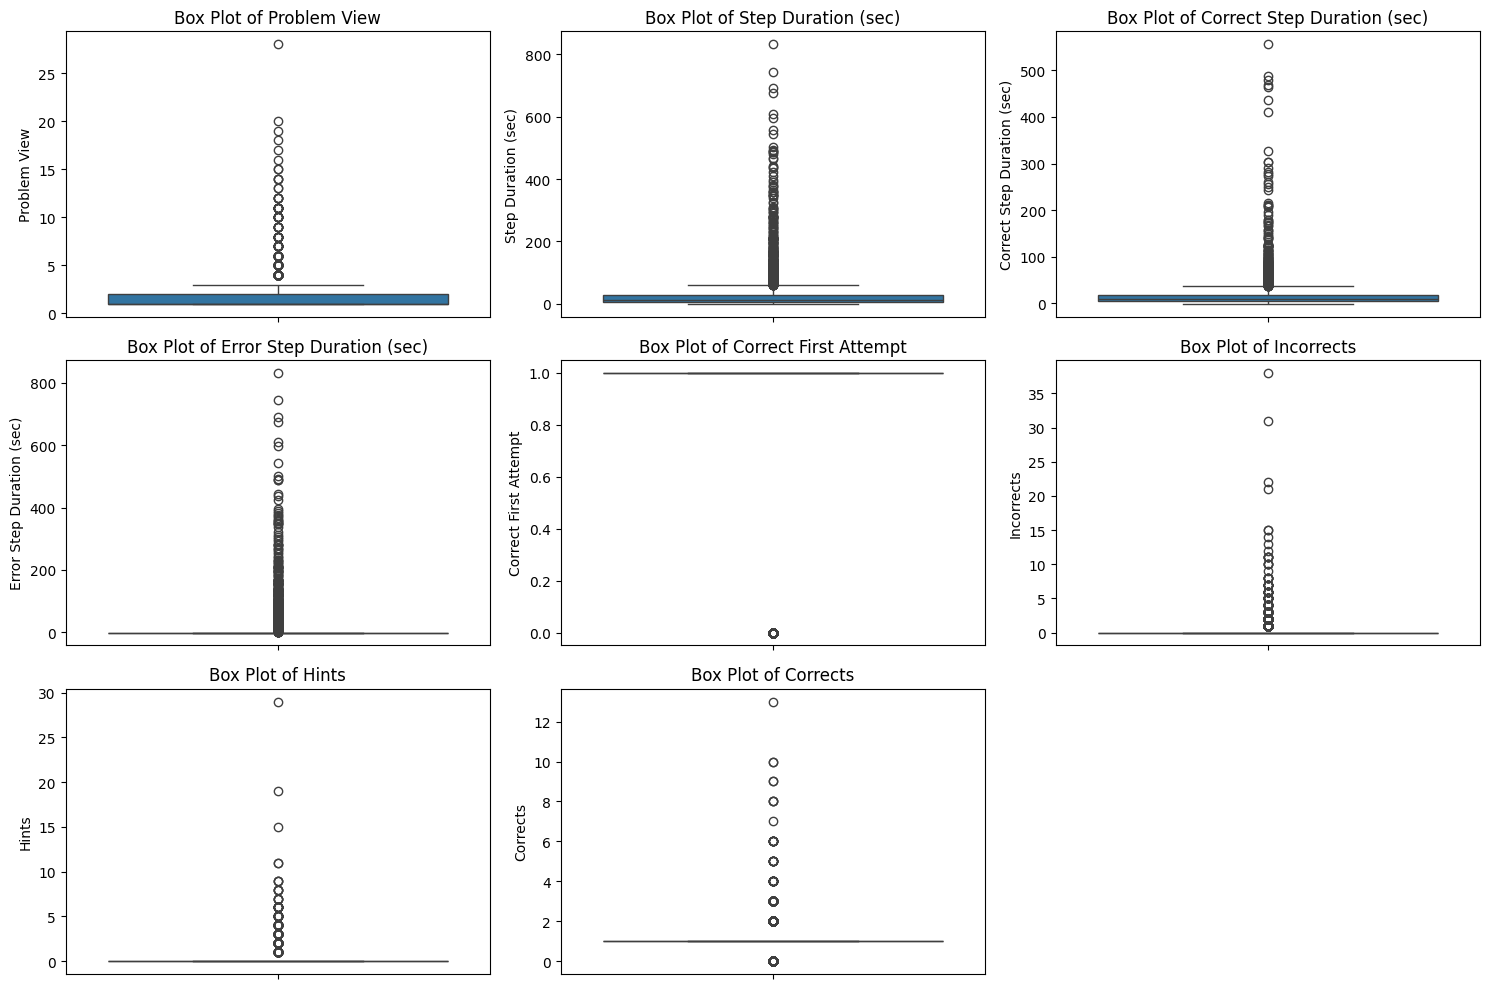

In [37]:
print("\n" + "="*60)
print("Detecting noise through visualisation...")

# Select numerical columns for visualization (excluding binary/dummy variables)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude binary columns created from KC and Opportunity (assuming they start with 'KC_' or 'Opp_')
numerical_cols = [col for col in numerical_cols if not col.startswith('KC_') and not col.startswith('Opp_')]

# Exclude binned columns
numerical_cols = [col for col in numerical_cols if '_Binned' not in col]

# Exclude student ID and other non-numeric/non-binned columns
exclude_cols = ['Anon Student Id', 'Problem View', 'Step Duration (sec)',
                'Correct Step Duration (sec)', 'Error Step Duration (sec)',
                'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects',
                'Engagement_Level']
numerical_cols = [col for col in numerical_cols if col in exclude_cols]


print(f"Visualising potential noise in numerical columns: {numerical_cols}")

# Create box plots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

### 6. Filter to Top 20 Problem Hierarchies
Reduce dataset size by keeping only top 20 most frequent problem hierarchies

In [38]:
print("\n" + "="*60)
print("Filtering to top 20 Problem Hierarchies...")

top_20_hierarchies = df['Problem Hierarchy'].value_counts().head(20).index
df = df[df['Problem Hierarchy'].isin(top_20_hierarchies)]

print(f"Filtered to top 20 problem hierarchies")
print(f"New shape: {df.shape}")
print(f"\nTop 20 Problem Hierarchies:")
print(df['Problem Hierarchy'].value_counts())


Filtering to top 20 Problem Hierarchies...
Filtered to top 20 problem hierarchies
New shape: (1883, 14)

Top 20 Problem Hierarchies:
Problem Hierarchy
Unit CTA1_08, Section CTA1_08-3                                          208
Unit CTA1_13, Section CTA1_13-1                                          193
Unit CTA1_01, Section CTA1_01-3                                          137
Unit CTA1_02, Section CTA1_02-4                                          127
Unit CTA1_06, Section CTA1_06-4                                           98
Unit ES_07, Section ES_07-4                                               89
Unit LINEAR-INEQUALITY-GRAPHING, Section LINEAR-INEQUALITY-GRAPHING-2     89
Unit CTA1_14, Section CTA1_14-4                                           86
Unit CTA1_02, Section CTA1_02-3                                           84
Unit CTA1_04, Section CTA1_04-3                                           81
Unit ES_03, Section ES_03-6                                               77
U

### 7. Engineer Engagement Level Feature
Track student engagement by counting their cumulative interactions

In [39]:
print("\n" + "="*60)
print("Engineering Engagement Level feature...")

# Sort by student and ensure proper ordering if there's a timestamp
df = df.sort_values(['Anon Student Id']).reset_index(drop=True)

# Create cumulative engagement counter per student
df['Engagement_Level'] = df.groupby('Anon Student Id').cumcount() + 1

print(f"Created Engagement_Level column")
print(f"Engagement Level statistics:")
print(df['Engagement_Level'].describe())


Engineering Engagement Level feature...
Created Engagement_Level column
Engagement Level statistics:
count    1883.000000
mean        3.962825
std         3.451916
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        31.000000
Name: Engagement_Level, dtype: float64


## 8. Process KC (Knowledge Component) Column
Split multi-valued KC column into binary columns for each knowledge component

In [40]:
print("\n" + "="*60)
print("Processing KC(Default) column...")

# Handle missing values first
df['KC(Default)'].fillna('Unknown', inplace=True)

# Get all unique KCs across all rows
all_kcs = set()
for kc_string in df['KC(Default)']:
    if pd.notna(kc_string) and kc_string != 'Unknown':
        kcs = [kc.strip() for kc in str(kc_string).split('~~')]
        all_kcs.update(kcs)

print(f"Found {len(all_kcs)} unique knowledge components")

# Create binary column for each KC
for kc in sorted(all_kcs):
    col_name = f'KC_{kc.replace(" ", "_").replace("-", "_")}'
    df[col_name] = df['KC(Default)'].apply(
        lambda x: 1 if kc in str(x) else 0
    )

print(f"Created {len(all_kcs)} binary KC columns")
print(f"\nSample KC columns:")
kc_cols = [col for col in df.columns if col.startswith('KC_')]
print(kc_cols[:10])


Processing KC(Default) column...
Found 78 unique knowledge components
Created 78 binary KC columns

Sample KC columns:
['KC_Changing_axis_bounds', 'KC_Changing_axis_intervals', 'KC_Convert_unit,_mixed', 'KC_Convert_unit,_standard', 'KC_Correctly_placing_points', 'KC_Define_Variable', 'KC_Entering_a_computed_linear_value', 'KC_Entering_a_computed_quadratic_value', 'KC_Entering_a_given', 'KC_Entering_a_given_linear_value']


## 9. Process Opportunity Column
Split multi-valued Opportunity column similar to KC

In [41]:
print("\n" + "="*60)
print("Processing Opportunity(Default) column...")

# Check if Opportunity column has ~~ separators
has_separators = df['Opportunity(Default)'].astype(str).str.contains('~~').sum()
print(f"Rows with ~~ separator in Opportunity: {has_separators}")

if has_separators > 0:
    # Get all unique opportunities
    all_opps = set()
    for opp_string in df['Opportunity(Default)']:
        if pd.notna(opp_string):
            opps = [opp.strip() for opp in str(opp_string).split('~~')]
            all_opps.update(opps)

    print(f"Found {len(all_opps)} unique opportunities")

    # Create binary column for each opportunity
    for opp in sorted(all_opps):
        col_name = f'Opp_{opp.replace(" ", "_").replace("-", "_")}'
        df[col_name] = df['Opportunity(Default)'].apply(
            lambda x: 1 if opp in str(x) else 0
        )

    print(f"Created {len(all_opps)} binary Opportunity columns")
else:
    print("No multi-valued opportunities found. Column will be binned later.")


Processing Opportunity(Default) column...
Rows with ~~ separator in Opportunity: 476
Found 337 unique opportunities
Created 337 binary Opportunity columns


## 10. PCA

Principal Component Analysis (PCA) is used here to reduce the dimensionality of the features while retaining most of the data's variance.


Implementing PCA...
Selected 830 features for PCA.


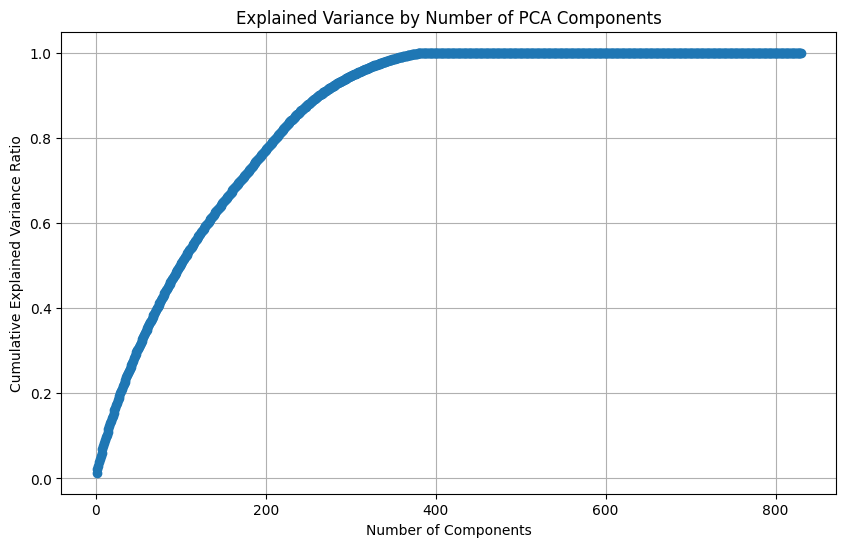


Number of components to explain 95% variance: 305

PCA complete. Reduced dimensionality to 305 components.

Principal Components DataFrame head:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_297,PC_298,PC_299,PC_300,PC_301,PC_302,PC_303,PC_304,PC_305,Anon Student Id
0,-3.156141,0.632599,0.618270,-0.349357,1.025003,-0.134462,-0.266697,0.402808,-0.102252,-0.122223,...,0.024481,-0.007522,0.027635,0.005234,0.011904,-0.033690,0.013279,-0.001506,-0.026609,02ZjVTxC34
1,7.725516,-3.186751,1.708644,-3.533679,3.881874,1.276800,2.838740,3.690645,2.338249,-0.626501,...,0.765234,2.251602,-0.769181,-1.197185,1.804840,0.420953,0.213186,-0.357633,1.971063,02ZjVTxC34
2,-0.912696,0.089043,1.690960,-4.722038,-1.995282,-2.663632,1.559832,0.345390,-2.319766,2.622214,...,-1.433008,0.321218,-0.685056,2.375056,0.283757,-0.200207,0.774012,2.030947,2.074594,02ZjVTxC34
3,8.169880,-1.758785,-0.813797,-5.107634,6.050733,1.890676,3.153560,-2.820759,-0.896553,6.935142,...,0.310443,-0.122918,-2.025218,-1.051333,1.383690,-0.872932,-0.598495,0.009366,-2.920991,02ZjVTxC34
4,1.093201,-2.622091,-0.873157,-5.423728,-1.781490,1.361010,-2.642488,-1.401377,2.690654,-0.667592,...,-1.121653,-1.092353,0.326682,0.315456,-0.427624,0.697247,0.399322,0.431319,0.245069,02i5jCrfQK



Explained variance ratio of the selected components:


array([0.01343174, 0.0086636 , 0.00815586, 0.00798923, 0.00760074,
       0.00748267, 0.00735394, 0.00734034, 0.0072287 , 0.00716178,
       0.00701382, 0.00691573, 0.00672527, 0.00661194, 0.00654855,
       0.00651108, 0.00636323, 0.00631581, 0.00628512, 0.00610463,
       0.00602466, 0.00601316, 0.00590264, 0.00588658, 0.0057555 ,
       0.00569458, 0.00568676, 0.00558297, 0.00555633, 0.00549186,
       0.0054401 , 0.00537692, 0.00534939, 0.00528289, 0.00520831,
       0.00519239, 0.00509319, 0.00505358, 0.00503358, 0.00501152,
       0.00498712, 0.00494739, 0.00484769, 0.00480953, 0.00478924,
       0.0047685 , 0.00471225, 0.00467391, 0.00464447, 0.00458965,
       0.00454874, 0.00453487, 0.00452221, 0.00447249, 0.00444136,
       0.00441768, 0.00437383, 0.00434498, 0.00433103, 0.00431042,
       0.0042926 , 0.004249  , 0.00424695, 0.00420639, 0.00419039,
       0.00416001, 0.00413744, 0.00411053, 0.00409656, 0.00408968,
       0.00405099, 0.00404104, 0.00401858, 0.00398487, 0.00398

In [42]:
print("\n" + "="*60)
print("Implementing PCA...")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical and binary/dummy columns for PCA
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
binary_cols = [col for col in df.columns if col.startswith('KC_') or col.startswith('Opp_')]

# Combine numerical and binary columns, excluding the original non-processed ones
pca_features = [col for col in numerical_cols if col not in ['Problem View', 'Step Duration (sec)', 'Correct Step Duration (sec)', 'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'Engagement_Level', 'Opportunity(Default)']] + binary_cols

# Exclude non-feature columns like student ID
pca_features = [col for col in pca_features if col not in ['Anon Student Id']]

print(f"Selected {len(pca_features)} features for PCA.")

# Handle any potential remaining missing values in the selected features
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[pca_features] = imputer.fit_transform(df[pca_features])

# Standardize the features before applying PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[pca_features])

# Apply PCA
# Start by keeping all components to examine explained variance
pca = PCA()
pca.fit(scaled_features)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Explained Variance by Number of PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# Decide on the number of components based on the elbow plot or a threshold (e.g., 95% variance)

n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"\nNumber of components to explain 95% variance: {n_components}")

# Re-run PCA with the selected number of components
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(scaled_features)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=[f'PC_{i+1}' for i in range(n_components)])

# Ensure the index is aligned if merging
pca_df['Anon Student Id'] = df['Anon Student Id'].reset_index(drop=True)

print(f"\nPCA complete. Reduced dimensionality to {n_components} components.")
print("\nPrincipal Components DataFrame head:")
display(pca_df.head())

print("\nExplained variance ratio of the selected components:")
display(pca.explained_variance_ratio_)

## 11. Bin Continuous Numerical Columns
Create categorical bins for continuous features

In [43]:
print("\n" + "="*60)
print("Binning continuous numerical columns...")

# Problem View - 4 bins
df['Problem_View_Binned'] = pd.cut(df['Problem View'], bins=4, labels=['Low', 'Medium', 'High', 'Very_High'])
print(f"Binned Problem View into 4 categories")
print(df['Problem_View_Binned'].value_counts())

# Corrects - 2 bins
df['Corrects_Binned'] = pd.cut(df['Corrects'], bins=2, labels=['Few', 'Many'])
print(f"\nBinned Corrects into 2 categories")
print(df['Corrects_Binned'].value_counts())

# Incorrects - 2 bins
df['Incorrects_Binned'] = pd.cut(df['Incorrects'], bins=2, labels=['Few', 'Many'])
print(f"\nBinned Incorrects into 2 categories")
print(df['Incorrects_Binned'].value_counts())

# Hints - 2 bins
df['Hints_Binned'] = pd.cut(df['Hints'], bins=2, labels=['Few', 'Many'])
print(f"\nBinned Hints into 2 categories")
print(df['Hints_Binned'].value_counts())


Binning continuous numerical columns...
Binned Problem View into 4 categories
Problem_View_Binned
Low          1864
Medium         15
High            2
Very_High       2
Name: count, dtype: int64

Binned Corrects into 2 categories
Corrects_Binned
Few     1878
Many       5
Name: count, dtype: int64

Binned Incorrects into 2 categories
Incorrects_Binned
Few     1881
Many       2
Name: count, dtype: int64

Binned Hints into 2 categories
Hints_Binned
Few     1882
Many       1
Name: count, dtype: int64


In [44]:
# Step Duration - 15 bins (using quantile-based binning for better distribution)
temp_binned = pd.qcut(df['Step Duration (sec)'], q=15, duplicates='drop')
n_bins = temp_binned.nunique()
df['Step_Duration_Binned'] = pd.qcut(
    df['Step Duration (sec)'],
    q=15,
    labels=[f'SD_{i+1}' for i in range(n_bins)],
    duplicates='drop'
)
print(f"\nBinned Step Duration into {n_bins} quantile-based categories")
print(df['Step_Duration_Binned'].value_counts().sort_index())

# Correct Step Duration - 15 bins (handle -1 sentinel value)
mask_positive = df['Correct Step Duration (sec)'] > 0
df['Correct_Step_Duration_Binned'] = 'No_Correct_Step'
if mask_positive.sum() > 0:
    temp_binned = pd.qcut(
        df.loc[mask_positive, 'Correct Step Duration (sec)'],
        q=15,
        duplicates='drop'
    )
    n_bins = temp_binned.nunique()
    df.loc[mask_positive, 'Correct_Step_Duration_Binned'] = pd.qcut(
        df.loc[mask_positive, 'Correct Step Duration (sec)'],
        q=15,
        labels=[f'CSD_{i+1}' for i in range(n_bins)],
        duplicates='drop'
    ).astype(str)
    print(f"\nBinned Correct Step Duration into {n_bins} categories (excluding -1 sentinel)")
print(df['Correct_Step_Duration_Binned'].value_counts())

# Error Step Duration - 15 bins (handle -1 sentinel value)
mask_positive = df['Error Step Duration (sec)'] > 0
df['Error_Step_Duration_Binned'] = 'No_Error'
if mask_positive.sum() > 0:
    temp_binned = pd.qcut(
        df.loc[mask_positive, 'Error Step Duration (sec)'],
        q=15,
        duplicates='drop'
    )
    n_bins = temp_binned.nunique()
    df.loc[mask_positive, 'Error_Step_Duration_Binned'] = pd.qcut(
        df.loc[mask_positive, 'Error Step Duration (sec)'],
        q=15,
        labels=[f'ESD_{i+1}' for i in range(n_bins)],
        duplicates='drop'
    ).astype(str)
    print(f"\nBinned Error Step Duration into {n_bins} categories (excluding -1 sentinel)")
print(df['Error_Step_Duration_Binned'].value_counts())


Binned Step Duration into 15 quantile-based categories
Step_Duration_Binned
SD_1     226
SD_2     124
SD_3     118
SD_4     121
SD_5      81
SD_6     164
SD_7      56
SD_8     142
SD_9     101
SD_10    126
SD_11    127
SD_12    126
SD_13    120
SD_14    128
SD_15    123
Name: count, dtype: int64

Binned Correct Step Duration into 13 categories (excluding -1 sentinel)
Correct_Step_Duration_Binned
CSD_9              420
CSD_1              216
CSD_6              148
CSD_2              123
CSD_13             121
CSD_11             120
CSD_4              119
CSD_12             117
CSD_3              113
CSD_7              105
CSD_8               96
CSD_5               76
No_Correct_Step     57
CSD_10              52
Name: count, dtype: int64

Binned Error Step Duration into 15 categories (excluding -1 sentinel)
Error_Step_Duration_Binned
No_Error    1469
ESD_10        47
ESD_1         38
ESD_3         34
ESD_8         29
ESD_14        28
ESD_6         28
ESD_13        28
ESD_12        27
E

In [45]:
# Bin Engagement Level
df['Engagement_Level_Binned'] = pd.cut(
    df['Engagement_Level'],
    bins=[0, 10, 50, 200, float('inf')],
    labels=['Light', 'Medium', 'Heavy', 'Very_Heavy']
)
print(f"\nBinned Engagement Level into 4 categories")
print(df['Engagement_Level_Binned'].value_counts())


Binned Engagement Level into 4 categories
Engagement_Level_Binned
Light         1794
Medium          89
Heavy            0
Very_Heavy       0
Name: count, dtype: int64


## 12. Handle Opportunity Column Binning (if not multi-valued)

In [46]:
# If Opportunity is numerical, bin it
if df['Opportunity(Default)'].dtype in ['int64', 'float64']:
    print("\n" + "="*60)
    print("Binning Opportunity(Default) as numerical column...")
    df['Opportunity_Binned'] = pd.qcut(
        df['Opportunity(Default)'],
        q=5,
        labels=['Opp_1', 'Opp_2', 'Opp_3', 'Opp_4', 'Opp_5'],
        duplicates='drop'
    )
    print(df['Opportunity_Binned'].value_counts())

## 13. Final Dataset Overview

In [47]:
print("\n" + "="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"\nFinal dataset shape: {df.shape}")
print(f"Original shape: {df.shape}")
print(f"\nColumns in preprocessed dataset:")
print(df.columns.tolist())
print(f"\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nData types:")
print(df.dtypes.value_counts())


PREPROCESSING COMPLETE

Final dataset shape: (1883, 438)
Original shape: (1883, 438)

Columns in preprocessed dataset:
['Anon Student Id', 'Problem Hierarchy', 'Problem Name', 'Problem View', 'Step Name', 'Step Duration (sec)', 'Correct Step Duration (sec)', 'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'KC(Default)', 'Opportunity(Default)', 'Engagement_Level', 'KC_Changing_axis_bounds', 'KC_Changing_axis_intervals', 'KC_Convert_unit,_mixed', 'KC_Convert_unit,_standard', 'KC_Correctly_placing_points', 'KC_Define_Variable', 'KC_Entering_a_computed_linear_value', 'KC_Entering_a_computed_quadratic_value', 'KC_Entering_a_given', 'KC_Entering_a_given_linear_value', 'KC_Entering_a_given_quadratic_value', 'KC_Entering_a_point', 'KC_Entering_slope,_SIF', 'KC_Entering_the_slope', 'KC_Entering_the_y_intercept', 'KC_Entering_x_intercept,_GLF', 'KC_Entering_x_intercept,_SIF', 'KC_Entering_y_intercept,_GLF', 'KC_Entering_y_intercept,_SIF', 'KC_Excluding_t

In [48]:
# Display sample of preprocessed data
df.head(10)

,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,...,Opp_98,Opp_99,Problem_View_Binned,Corrects_Binned,Incorrects_Binned,Hints_Binned,Step_Duration_Binned,Correct_Step_Duration_Binned,Error_Step_Duration_Binned,Engagement_Level_Binned
0,02ZjVTxC34,"Unit CTA1_01, Section CTA1_01-3",L5FB03B,1,R1C1,67.0,17.96007,67.0,0,1,...,0.0,0.0,Low,Few,Few,Few,SD_14,CSD_9,ESD_11,Light
1,02ZjVTxC34,"Unit CTA1_02, Section CTA1_02-3",BH1T39C,2,R8C1,4.0,4.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_2,CSD_2,No_Error,Light
2,02ZjVTxC34,"Unit CTA1_04, Section CTA1_04-4",L5FB04,1,R7C2,7.0,7.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_5,CSD_5,No_Error,Light
3,02ZjVTxC34,"Unit CTA1_13, Section CTA1_13-1",PROP06,1,R4C1,124.0,17.96007,124.0,0,3,...,0.0,0.0,Low,Few,Few,Few,SD_15,CSD_9,ESD_13,Light
4,02i5jCrfQK,"Unit CTA1_13, Section CTA1_13-1",PROP01,1,2F = 3000,6.0,6.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_4,CSD_4,No_Error,Light
5,02i5jCrfQK,"Unit CTA1_15, Section CTA1_15-3",SYS07,1,R5C3,7.0,7.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_5,CSD_5,No_Error,Light
6,02i5jCrfQK,"Unit LINEAR-INEQUALITY-GRAPHING, Section LINEA...",YLT3X+5,1,GraphButton1,1.0,1.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_1,CSD_1,No_Error,Light
7,02i5jCrfQK,"Unit CTA1_14, Section CTA1_14-4",2PTFB10,1,51+7H = 72,5.0,5.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_3,CSD_3,No_Error,Light
8,02i5jCrfQK,"Unit ES_02, Section ES_02-10",EG44,7,row1-D-y,4.0,4.00000,-1.0,1,0,...,0.0,0.0,Medium,Few,Few,Few,SD_2,CSD_2,No_Error,Light
9,02i5jCrfQK,"Unit CTA1_08, Section CTA1_08-3",BH1T07,1,YUnit,3.0,3.00000,-1.0,1,0,...,0.0,0.0,Low,Few,Few,Few,SD_1,CSD_1,No_Error,Light


## 14. Save Preprocessed Dataset

In [49]:
# Save preprocessed dataset
output_path = './algebra_preprocessed.csv'
df.to_csv(output_path, index=False)
print(f"\nPreprocessed dataset saved to: {output_path}")


Preprocessed dataset saved to: ./algebra_preprocessed.csv


## Summary of Changes

### Completed Preprocessing Tasks:

1. **Error Step Duration Handling**
   - Imputed -1 for rows where Incorrects == 0
   - Mean imputation for actual missing values

2. **Correct Step Duration & Transaction Time**
   - Mean imputation for contradictory cases
   - Sentinel value -1 for no correct step

3. **Dropped Columns**
   - Removed Row and all timestamp columns

4. **Handle Remaining Missing Values**
   - Numerical Columns: Imputed with the mean.
    - Categorical Columns: Imputed with the mode.


4. **Dataset Size Reduction**
   - Filtered to top 20 Problem Hierarchies
5. **Detect Noise through Visualisation**
    - Visualise numerical features using scatter plots or box plot to identify potential outliers or unusual patterns that might indicate noise.

5. **Engagement Level Feature**
   - Created running counter per student

6. **KC Column Processing**
   - Split multi-valued column into binary features

7. **Opportunity Column Processing**
   - Handled both multi-valued and numerical cases
7. **PCA**
    - Principal Component Analysis (PCA) is used to reduce the dimensionality of the features while retaining most of the data's variance.

8. **Binning Continuous Features**
   - Problem View (4 bins)
   - Corrects, Incorrects, Hints (2 bins each)
   - Step Duration, Correct/Error Step Duration (15 bins each)
   - Engagement Level (4 bins)

### Ready for Association Rule Mining
The dataset is now prepared with:
- No missing values
- Appropriate binning for continuous features
- Binary encoding for multi-valued categorical features
- Reduced dimensionality while preserving information